# Parameter displacement: initialisation → end of training

Each network parameter is drawn as one spoke of a radial ("spider") plot. The
**radius is the per-parameter displacement** between initialisation and the end of
training, and the **centre of the circle = the end-of-training parameters**
(displacement 0). Plots show a **single replica** (set `replica` below) and a
chosen parameter kind (`param_kind` ∈ `"weights"`, `"biases"`, `"all"`); spokes are
coloured by network layer.

Two reference choices are shown for *end of training* — each replica's **best
(early-stopping) epoch**, and the **final epoch** — and two displacement metrics
— **absolute** $|\Delta\theta|$ and **normalised** $|\Delta\theta|/|\theta_\text{end}|$.

*Initialisation* uses the `params_0` snapshot if present, otherwise it falls back
to the earliest stored epoch (the genuine init is only saved by fits run after the
`StoreCallback.on_train_begin` patch).

In [1]:
%matplotlib inline
import logging
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from ntkpdf.api import API  # importing applies the NTKPDF plotting style

logging.basicConfig(level=logging.INFO)

fit = "260622-ac-03-ntk-sgd-long"

Applying NTKPDF plotting style...
Using Keras backend


In [2]:
SAVEPATH = pathlib.Path.cwd() / "figs" / "parameter_distance" / fit
SAVEPATH.mkdir(parents=True, exist_ok=True)

In [3]:
stored_epochs = sorted(API.stored_epochs(fit=fit))
best_epochs = API.best_epochs(fit=fit).data.flatten().astype(int).tolist()


def init_weights(fit):
    """Weights at initialisation: params_0 if saved, else the earliest stored epoch."""
    try:
        w = API.fit_weights(fit=fit, epoch=0)
        logging.info("Using genuine initialisation snapshot (epoch 0).")
    except FileNotFoundError:
        epoch = stored_epochs[0]
        logging.info(f"No params_0 snapshot; falling back to earliest stored epoch {epoch}.")
        w = API.fit_weights(fit=fit, epoch=epoch)
    return np.asarray(w)


# (nreplicas, nparams) arrays
w_init = init_weights(fit)
w_best = np.asarray(API.fit_weights(fit=fit, epoch=best_epochs))   # per-replica best epoch
w_final = np.asarray(API.fit_weights(fit=fit, epoch=stored_epochs[-1]))  # final epoch

print("shapes:", w_init.shape, w_best.shape, w_final.shape)
print("best epochs:", best_epochs, "| final epoch:", stored_epochs[-1])

shapes: (5, 763) (5, 763) (5, 763)
best epochs: [49988, 49999, 31314, 49999, 46294] | final epoch: 50000


In [4]:
def displacement(w_init, w_end, metric):
    """Per-parameter displacement, shape (nreplicas, nparams)."""
    delta = np.abs(w_init - w_end)
    if metric == "absolute":
        return delta
    if metric == "normalised":
        # eps guards parameters whose end-of-training value is ~0
        return delta / (np.abs(w_end) + 1e-8)
    raise ValueError(metric)


# Per-tensor segments of the flat parameter vector. all_NNs alternates
# (kernel, bias) for each dense layer, so tag each segment by its layer and kind
# ("weights" = 2D kernel, "biases" = 1D bias) to allow filtering them.
shapes = [list(v.shape) for v in API.metamodels(fit=fit).get_replica_weights(0)["all_NNs"]]
sizes = [int(np.prod(s)) for s in shapes]
bounds = np.cumsum([0] + sizes)
segments = [
    {"start": bounds[i], "end": bounds[i + 1],
     "layer": i // 2,
     "kind": "weights" if len(s) == 2 else "biases"}
    for i, s in enumerate(shapes)
]
n_layers = len(shapes) // 2
print("nparams:", bounds[-1], "| segments:", segments)

INFO:2026-07-10 10:28:35,172:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


nparams: 763 | segments: [{'start': np.int64(0), 'end': np.int64(50), 'layer': 0, 'kind': 'weights'}, {'start': np.int64(50), 'end': np.int64(75), 'layer': 0, 'kind': 'biases'}, {'start': np.int64(75), 'end': np.int64(575), 'layer': 1, 'kind': 'weights'}, {'start': np.int64(575), 'end': np.int64(595), 'layer': 1, 'kind': 'biases'}, {'start': np.int64(595), 'end': np.int64(755), 'layer': 2, 'kind': 'weights'}, {'start': np.int64(755), 'end': np.int64(763), 'layer': 2, 'kind': 'biases'}]


In [5]:
def plot_param_spider(w_end, *, metric, title, replica, param_kind, rscale="linear", rmax=None):
    d_full = displacement(w_init, w_end, metric)[replica]  # single replica
    segs = [s for s in segments if param_kind == "all" or s["kind"] == param_kind]
    d = np.concatenate([d_full[s["start"]:s["end"]] for s in segs])
    theta = np.linspace(0, 2 * np.pi, d.size, endpoint=False)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # one colour per layer
    colors = plt.cm.viridis(np.linspace(0, 0.85, n_layers))
    seen, pos = set(), 0
    for s in segs:
        sl = slice(pos, pos + s["end"] - s["start"])
        label = f"layer {s['layer'] + 1}" if s["layer"] not in seen else None
        seen.add(s["layer"])
        ax.scatter(theta[sl], d[sl], color=colors[s["layer"]], s=5, label=label)
        pos = sl.stop

    # radial scale: "linear", "log", or "symlog" (symlog/log tame off-scale outliers
    # in the normalised metric); rmax optionally caps the radius.
    ax.set_rscale(rscale)
    if rmax is not None:
        ax.set_rmax(rmax)

    ax.set_xticklabels([])
    # ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
    fig.tight_layout()
    return fig

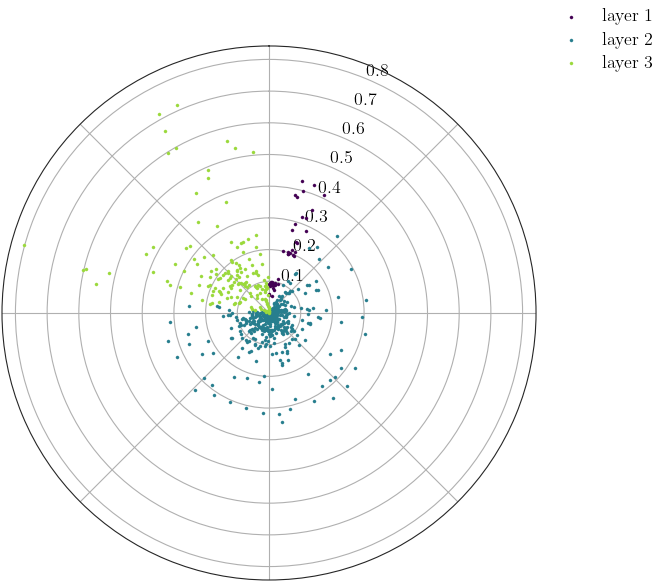

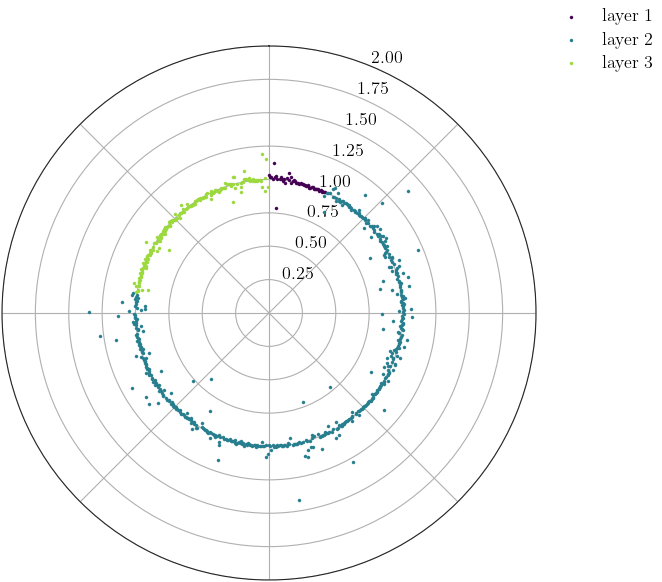

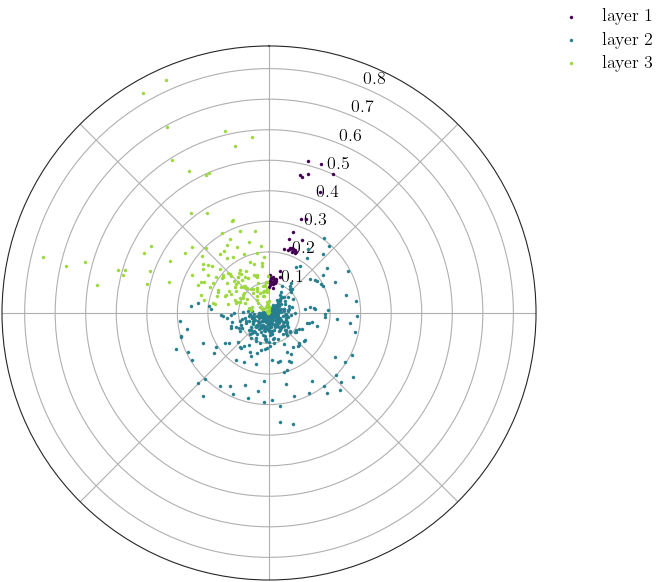

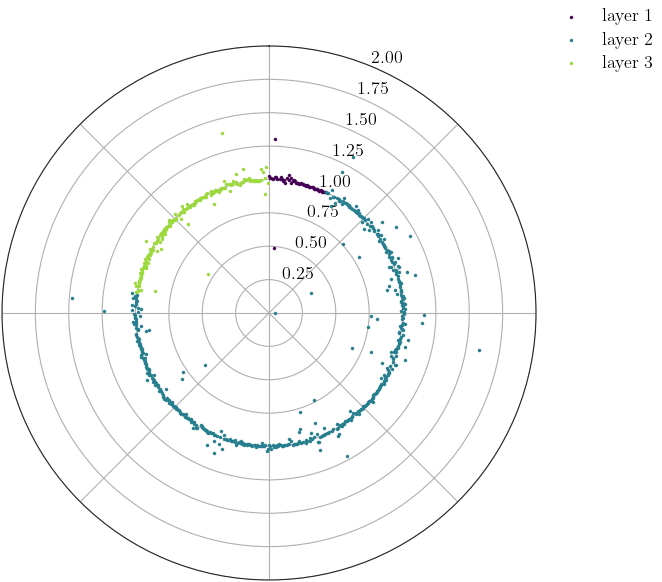

In [6]:
replica = 2       # which replica to plot
param_kind = "weights"  # "weights", "biases", or "all"
rscale = "linear"  # radial scale: "linear", "log", or "symlog"
rmax_abs = None     # optional radius cap (e.g. 1.0); None = autoscale
rmax_norm = 2.0     # optional radius cap (e.g. 0.5); None = autoscale

ends = {"best epoch": w_best, "final epoch": w_final} #{"final epoch": w_final}
metrics = ["absolute", "normalised"]

for end_name, w_end in ends.items():
    for metric in metrics:
        label = r"$|\Delta\theta|$" if metric == "absolute" else r"$|\Delta\theta| / |\theta_\mathrm{end}|$"
        fig = plot_param_spider(
            w_end,
            metric=metric,
            replica=replica,
            param_kind=param_kind,
            rscale=rscale,
            rmax=rmax_abs if metric == "absolute" else rmax_norm,
            title=f"Replica {replica} ({param_kind}) — displacement to {end_name}  —  {label}",
        )
        display(fig)
        # fig.savefig(SAVEPATH / f"replica{replica}_{param_kind}_{end_name.replace(' ', '_')}_{metric}.pdf", bbox_inches="tight", dpi=300)
        plt.close(fig)

## Animating the displacement across training

The static plots above show only the endpoints. Here the same radial plot is animated over
the stored epoch snapshots, so one can see *when* each parameter moves.

The convention flips: the **centre of the circle is now the initialisation**, and the radius
is the normalised distance travelled so far,

$$r(t) = \frac{|\theta(t) - \theta_\text{init}|}{|\theta_\text{init}|},$$

so every spoke starts at 0 and grows outward. The radial limit is **frozen across frames**
(autoscaling would make the whole plot breathe and hide the growth), and the radial scale is
necessarily linear — the first frame is identically 0, where `log` is undefined.

Two caveats specific to normalising by the *initialisation*:

- **Weights only.** The biases are initialised to exactly zero, so $|\theta_\text{init}| = 0$
  and the ratio is a pure artifact of the `1e-8` guard (radii $\sim 10^7$). The cell below
  asserts `param_kind == "weights"`; for biases use the absolute metric instead.
- The ratio has a heavy tail (a handful of weights start near zero and reach $r \sim 40$),
  so the radius is capped at `rmax_norm` — the same cap used by the static plots above.

Output is a GIF written next to the PDFs in `SAVEPATH`.

In [7]:
stride = 2  # 402 snapshots -> 201 frames; raise to shrink the GIF, 1 = every snapshot

# biases are zero at init, so |dtheta| / |theta_init| is meaningless for them
assert param_kind == "weights", "the from-init normalised radius is only defined for weights"

traj_epochs = stored_epochs[::stride]
w_traj = np.stack(
    [np.asarray(API.fit_weights(fit=fit, epoch=e))[replica] for e in traj_epochs]
)  # (n_frames, nparams)

# displacement() normalises by its *second* argument, so passing the init as the
# reference gives |theta(t) - theta_init| / |theta_init|.
d_traj = displacement(w_traj, w_init[replica], "normalised")

assert d_traj.shape == (len(traj_epochs), w_traj.shape[1])
assert not d_traj[0].any()  # frame 0 is the init: every radius is exactly 0
print("frames:", len(traj_epochs), "| epochs:", traj_epochs[0], "->", traj_epochs[-1])

frames: 501 | epochs: 0 -> 50000


In [8]:
import matplotlib.animation as animation


def animate_param_spider(d_traj, epochs, *, param_kind, rmax):
    """Spider plot of d_traj[t] per frame; returns (anim, fig)."""
    segs = [s for s in segments if param_kind == "all" or s["kind"] == param_kind]
    d = np.concatenate([d_traj[:, s["start"]:s["end"]] for s in segs], axis=1)
    theta = np.linspace(0, 2 * np.pi, d.shape[1], endpoint=False)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    colors = plt.cm.viridis(np.linspace(0, 0.85, n_layers))
    scatters, seen, pos = [], set(), 0
    for s in segs:
        sl = slice(pos, pos + s["end"] - s["start"])
        label = f"layer {s['layer'] + 1}" if s["layer"] not in seen else None
        seen.add(s["layer"])
        scatters.append((ax.scatter(theta[sl], d[0, sl], color=colors[s["layer"]], s=5, label=label), sl))
        pos = sl.stop

    # frozen across frames: autoscaling would hide the outward growth. The few
    # weights that start near zero run off to r ~ 40 and are clipped.
    ax.set_rmax(rmax)
    ax.set_xticklabels([])
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
    title = ax.set_title(f"epoch {epochs[0]}", pad=20)
    fig.tight_layout()

    def update(t):
        for sc, sl in scatters:
            sc.set_offsets(np.c_[theta[sl], d[t, sl]])
        title.set_text(f"epoch {epochs[t]}")
        return [sc for sc, _ in scatters] + [title]

    anim = animation.FuncAnimation(fig, update, frames=len(epochs), blit=False)
    return anim, fig

In [9]:
fps = 20  # ~10 s of video at stride=2

anim, fig = animate_param_spider(
    d_traj, traj_epochs, param_kind=param_kind, rmax=rmax_norm
)
gifpath = SAVEPATH / f"replica{replica}_{param_kind}_from_init_normalised.gif"
anim.save(gifpath, writer=animation.PillowWriter(fps=fps), dpi=80)
plt.close(fig)
print(gifpath, f"({gifpath.stat().st_size / 1e6:.1f} MB)")

/Users/s2569857/Codes/NTKPDF/studies/figs/parameter_distance/260622-ac-03-ntk-sgd-long/replica2_weights_from_init_normalised.gif (1.3 MB)
